<a href="https://colab.research.google.com/github/dindahanifa/mechine_learning/blob/main/Project_data_marketing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# =====================================
# 🚀 Percepatan & Pengukuran Eksekusi
# =====================================

import time
# Pakai Numba (JIT Compiler) untuk mempercepat Python loop ---
from numba import njit

@njit
def fast_loop(n=10_000_000):
    total = 0
    for i in range(n):
        total += i ** 2
    return total

print("\n⚡ Mengukur waktu dengan Numba (JIT Compilation)...")
start = time.time()
fast_loop()
end = time.time()
print(f"Pertama kali (kompilasi): {end - start:.3f} detik")

start = time.time()
fast_loop()
end = time.time()
print(f"Eksekusi berikutnya: {end - start:.3f} detik")


⚡ Mengukur waktu dengan Numba (JIT Compilation)...
Pertama kali (kompilasi): 4.184 detik
Eksekusi berikutnya: 0.000 detik


# Import Library

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Mengkoneksikan ke data Bigquery

In [4]:
from google.colab import auth
auth.authenticate_user()

In [7]:
project_id = "marketing-project-482212"

# Buat client BigQuery
client = bigquery.Client(project=project_id)

In [9]:
query = """
SELECT
    ID,
    Year_Birth,
    Education,
    Marital_Status,
    Income,
    Kidhome,
    Teenhome,
    Country,
    Recency,
    (MntWines + MntFruits + MntMeatProducts + MntFishProducts + MntSweetProducts + MntGoldProds) AS TotalSpending,
    (NumDealsPurchases + NumWebPurchases + NumCatalogPurchases + NumStorePurchases) AS NumPurchases,
    Response
FROM `marketing-project-482212.marketing.marketing`
WHERE Recency IS NOT NULL
"""

# Load hasil query ke pandas DataFrame
df = client.query(query).to_dataframe()

In [14]:
query = """
  SELECT * FROM `marketing-project-482212.marketing.marketing`
"""
client.query(query).to_dataframe()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,1826,1970,Graduation,Divorced,84835,0,0,2014-06-16,0,189,...,6,1,0,0,0,0,0,1,0,Spain
1,1,1961,Graduation,Single,57091,0,0,2014-06-15,0,464,...,7,5,0,0,0,0,1,1,0,Canada
2,10476,1958,Graduation,Married,67267,0,1,2014-05-13,0,134,...,5,2,0,0,0,0,0,0,0,USA
3,1386,1967,Graduation,Together,32474,1,1,2014-05-11,0,10,...,2,7,0,0,0,0,0,0,0,Australia
4,5371,1989,Graduation,Single,21474,1,0,2014-04-08,0,6,...,2,7,1,0,0,0,0,1,0,Spain
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10142,1976,PhD,Divorced,66476,0,1,2013-03-07,99,372,...,11,4,0,0,0,0,0,0,0,USA
2236,5263,1977,2n Cycle,Married,31056,1,0,2013-01-22,99,5,...,3,8,0,0,0,0,0,0,0,Spain
2237,22,1976,Graduation,Divorced,46310,1,0,2012-12-03,99,185,...,5,8,0,0,0,0,0,0,0,Spain
2238,528,1978,Graduation,Married,65819,0,0,2012-11-29,99,267,...,10,3,0,0,0,0,0,0,0,India


# Cleaning Dataset

In [18]:
query = """
  SELECT * FROM `marketing-project-482212.marketing.marketing`
"""
client.query(query).to_dataframe()
print("Checking for missing value in the query result:")
print(client.query(query).to_dataframe().isnull().sum())

Checking for missing value in the query result:
ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Response                0
Complain                0
Country                 0
dtype: int64


# Info Column Data

In [21]:
# Convert 'Income' column to float to handle potential float median and NaN values gracefully
df['Income'] = df['Income'].astype(float)

# Calculate the median of the 'Income' column
income_median = df['Income'].median()

# Fill missing 'Income' values with the median
df['Income'].fillna(income_median, inplace=True)

print("\nMissing values after imputation:")
print(df.isnull().sum())


Missing values after imputation:
ID                0
Year_Birth        0
Education         0
Marital_Status    0
Income            0
Kidhome           0
Teenhome          0
Country           0
Recency           0
TotalSpending     0
NumPurchases      0
Response          0
dtype: int64


/tmp/ipython-input-4151638655.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Income'].fillna(income_median, inplace=True)


In [22]:
print("\nMenampilkan data setelah pembersihan:")
display(df.head())


Menampilkan data setelah pembersihan:


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Country,Recency,TotalSpending,NumPurchases,Response
0,1826,1970,Graduation,Divorced,84835.0,0,0,Spain,0,1190,15,1
1,1,1961,Graduation,Single,57091.0,0,0,Canada,0,577,18,1
2,10476,1958,Graduation,Married,67267.0,0,1,USA,0,251,11,0
3,1386,1967,Graduation,Together,32474.0,1,1,Australia,0,11,4,0
4,5371,1989,Graduation,Single,21474.0,1,0,Spain,0,91,8,1


# Describe Data

In [11]:
# Lihat info tipe kolom dan jumlah missing
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   ID              2240 non-null   Int64 
 1   Year_Birth      2240 non-null   Int64 
 2   Education       2240 non-null   object
 3   Marital_Status  2240 non-null   object
 4   Income          2216 non-null   Int64 
 5   Kidhome         2240 non-null   Int64 
 6   Teenhome        2240 non-null   Int64 
 7   Country         2240 non-null   object
 8   Recency         2240 non-null   Int64 
 9   TotalSpending   2240 non-null   Int64 
 10  NumPurchases    2240 non-null   Int64 
 11  Response        2240 non-null   Int64 
dtypes: Int64(9), object(3)
memory usage: 229.8+ KB


In [12]:
# Lihat ringkasan statistik numeric
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,TotalSpending,NumPurchases,Response
count,2240.0,2240.0,2216.0,2240.0,2240.0,2240.0,2240.0,2240.0,2240.0
mean,5592.159821,1968.805804,52247.251354,0.444196,0.50625,49.109375,605.798214,14.862054,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,602.249288,7.677173,0.356274
min,0.0,1893.0,1730.0,0.0,0.0,0.0,5.0,0.0,0.0
25%,2828.25,1959.0,35303.0,0.0,0.0,24.0,68.75,8.0,0.0
50%,5458.5,1970.0,51381.5,0.0,0.0,49.0,396.0,15.0,0.0
75%,8427.75,1977.0,68522.0,1.0,1.0,74.0,1045.5,21.0,0.0
max,11191.0,1996.0,666666.0,2.0,2.0,99.0,2525.0,44.0,1.0


## Business Problem

Berdasarkan dataset pemasaran yang telah dimuat, *business problem* yang dapat diidentifikasi adalah sebagai berikut:

**Bagaimana cara meningkatkan efektivitas kampanye pemasaran dan mendorong retensi pelanggan serta pengeluaran (spending) dengan lebih baik?**

1.  **Segmentasi Pelanggan**: Bisakah kita mengidentifikasi segmen pelanggan yang berbeda berdasarkan demografi, riwayat pembelian, dan respons terhadap kampanye sebelumnya?
2.  **Identifikasi Pelanggan Berisiko (Churn)**: Pelanggan seperti apa yang cenderung tidak merespons kampanye atau berhenti berbelanja?
3.  **Personalisasi Penawaran**: Penawaran atau kampanye jenis apa yang paling efektif untuk segmen pelanggan tertentu?
4.  **Optimalisasi Anggaran Pemasaran**: Bagaimana kita bisa mengalokasikan anggaran pemasaran secara lebih efisien untuk menargetkan pelanggan dengan potensi nilai seumur hidup (lifetime value) yang tinggi?
5.  **Pengaruh Demografi dan Perilaku**: Bagaimana faktor-faktor seperti tahun lahir, status pernikahan, jumlah anak/remaja di rumah, dan pendapatan memengaruhi perilaku pembelian dan respons terhadap kampanye?

In [23]:
numeric_cols = ['Income', 'Recency', 'TotalSpending', 'NumPurchases']
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[numeric_cols] = scaler.fit_transform(df[numeric_cols])

In [26]:
df_encoded = pd.get_dummies(df_scaled, columns=['Education', 'Marital_Status', 'Country'])

## Select Features for Clustering

Pilih fitur-fitur yang relevan dari `df_encoded` untuk digunakan dalam proses clustering. Kolom seperti 'ID' dan 'Response' akan dikecualikan karena tidak relevan untuk pembentukan segmen pelanggan.


In [27]:
columns_to_exclude = ['ID', 'Response']
features_for_clustering = [col for col in df_encoded.columns if col not in columns_to_exclude]
X = df_encoded[features_for_clustering]

print("Shape of X (features for clustering):", X.shape)
print("First 5 rows of X:")
display(X.head())

Shape of X (features for clustering): (2240, 28)
First 5 rows of X:


,Year_Birth,Income,Kidhome,Teenhome,Recency,TotalSpending,NumPurchases,Education_2n Cycle,Education_Basic,Education_Graduation,...,Marital_Status_Widow,Marital_Status_YOLO,Country_Australia,Country_Canada,Country_Germany,Country_India,Country_Mexico,Country_Saudi Arabia,Country_Spain,Country_USA
0,1970,1.302195,0,0,-1.696001,0.970250,0.017972,False,False,True,...,False,False,False,False,False,False,False,False,True,False
1,1961,0.193870,0,0,-1.696001,-0.047828,0.408829,False,False,True,...,False,False,False,True,False,False,False,False,False,False
2,1958,0.600384,0,1,-1.696001,-0.589253,-0.503169,False,False,True,...,False,False,False,False,False,False,False,False,False,True
3,1967,-0.789537,1,1,-1.696001,-0.987848,-1.415167,False,False,True,...,False,False,True,False,False,False,False,False,False,False
4,1989,-1.228968,1,0,-1.696001,-0.854983,-0.894025,False,False,True,...,False,False,False,False,False,False,False,False,True,False


## Determine the Optimal Number of Clusters (Elbow Method)

Tentukan jumlah cluster optimal untuk K-Means menggunakan metode Elbow. Metode ini melibatkan perhitungan Within-Cluster Sum of Squares (WCSS) untuk berbagai jumlah cluster dan memvisualisasikan hasilnya untuk menemukan 'siku' yang menunjukkan titik optimal.


WCSS values for 1 to 10 clusters: [336536.21696428536, 116274.73164303473, 67441.24320199147, 48949.011616666205, 39949.61846843232, 31398.234541183087, 26443.889711792, 23381.01541700899, 21381.531224490063, 20058.304596958384]


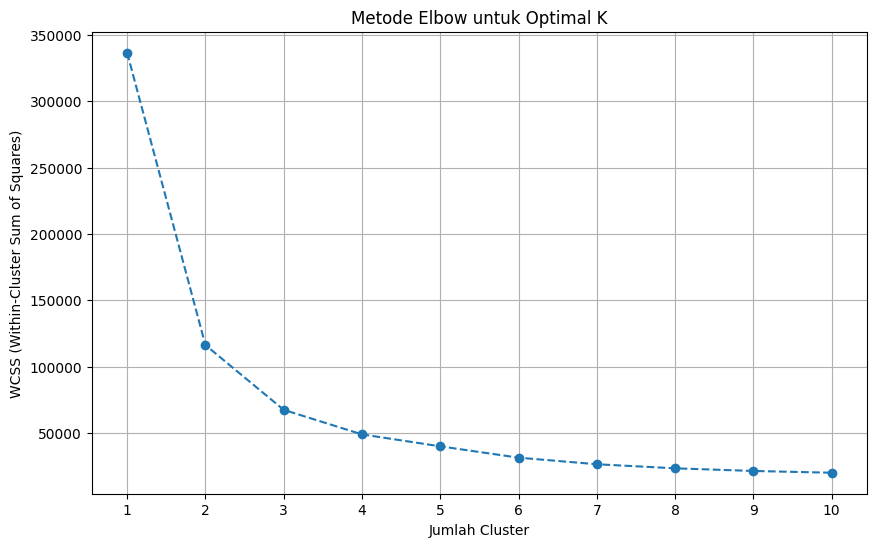

In [28]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10) # n_init=10 to suppress warning
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

print("WCSS values for 1 to 10 clusters:", wcss)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Metode Elbow untuk Optimal K')
plt.xlabel('Jumlah Cluster')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

---    
Berdasarkan plot 'Metode Elbow untuk Optimal K' yang dihasilkan, kita dapat mengamati perubahan tajam pada penurunan WCSS. Titik di mana penurunan WCSS mulai melambat secara signifikan disebut sebagai 'siku' atau 'elbow point'. Setelah titik ini, penambahan jumlah cluster tidak lagi memberikan pengurangan WCSS yang substansial.

Dari visualisasi di atas, **'elbow point' terlihat jelas di sekitar K = 3 atau K = 4**. Penurunan WCSS paling signifikan terjadi dari 1 ke 2 cluster, kemudian dari 2 ke 3 atau 4 cluster. Setelah itu, kurva mulai mendatar. Oleh karena itu, kita akan memilih **K = 3** sebagai jumlah cluster yang optimal untuk analisis segmentasi pelanggan ini, karena ini adalah titik di mana manfaat penambahan cluster mulai berkurang.


## Apply K-Means Clustering

Terapkan algoritma K-Means clustering pada data yang telah dipilih dengan jumlah cluster optimal yang telah ditentukan.

Langkah sebelumnya telah mengidentifikasi jumlah klaster optimal menggunakan metode Elbow. Sekarang, saya akan menginisialisasi dan melatih model K-Means dengan 3 klaster, seperti yang ditunjukkan oleh plot Elbow, pada set fitur `X` yang telah disiapkan.


In [29]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X)
print("K-Means model trained successfully with 3 clusters.")

K-Means model trained successfully with 3 clusters.


In [30]:
df_encoded['Cluster'] = kmeans.labels_
print("Cluster labels added to df_encoded DataFrame.")
print("First 5 rows with cluster labels:")
display(df_encoded.head())

Cluster labels added to df_encoded DataFrame.
First 5 rows with cluster labels:


,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,TotalSpending,NumPurchases,Response,Education_2n Cycle,...,Marital_Status_YOLO,Country_Australia,Country_Canada,Country_Germany,Country_India,Country_Mexico,Country_Saudi Arabia,Country_Spain,Country_USA,Cluster
0,1826,1970,1.302195,0,0,-1.696001,0.970250,0.017972,1,False,...,False,False,False,False,False,False,False,True,False,0
1,1,1961,0.193870,0,0,-1.696001,-0.047828,0.408829,1,False,...,False,False,True,False,False,False,False,False,False,1
2,10476,1958,0.600384,0,1,-1.696001,-0.589253,-0.503169,0,False,...,False,False,False,False,False,False,False,False,True,1
3,1386,1967,-0.789537,1,1,-1.696001,-0.987848,-1.415167,0,False,...,False,True,False,False,False,False,False,False,False,0
4,5371,1989,-1.228968,1,0,-1.696001,-0.854983,-0.894025,1,False,...,False,False,False,False,False,False,False,True,False,2


## Analyze Cluster Characteristics

Analisis karakteristik setiap klaster untuk memahami segmen pelanggan. Hal ini melibatkan pemeriksaan nilai rata-rata fitur-fitur utama untuk setiap klaster.

Untuk memahami karakteristik setiap segmen pelanggan, mengelompokkan DataFrame `df_encoded` berdasarkan kolom 'Cluster' yang baru dibuat dan menghitung rata-rata semua fitur numerik untuk setiap cluster.

In [31]:
cluster_characteristics = df_encoded.groupby('Cluster').mean()
print("Average characteristics of each cluster:")
display(cluster_characteristics)

Average characteristics of each cluster:


,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,TotalSpending,NumPurchases,Response,Education_2n Cycle,...,Marital_Status_Widow,Marital_Status_YOLO,Country_Australia,Country_Canada,Country_Germany,Country_India,Country_Mexico,Country_Saudi Arabia,Country_Spain,Country_USA
Cluster,,,,,,,,,,,,,,,,,,,,,
0,5443.588235,1970.26738,-0.057307,0.502674,0.607487,0.004940,-0.077304,-0.024527,0.140107,0.078075,...,0.027807,0.002139,0.071658,0.126203,0.058824,0.064171,0.001070,0.144385,0.491979,0.041711
1,5687.307582,1954.482117,0.223508,0.244635,0.685265,0.017023,0.189597,0.223745,0.145923,0.065808,...,0.071531,0.000000,0.078684,0.130186,0.052933,0.052933,0.001431,0.145923,0.482117,0.055794
2,5711.641914,1983.072607,-0.169389,0.584158,0.143564,-0.027257,-0.099421,-0.220239,0.166667,0.138614,...,0.001650,0.000000,0.062706,0.097360,0.046205,0.084158,0.001650,0.165017,0.491749,0.051155


## Visualize Cluster Characteristics


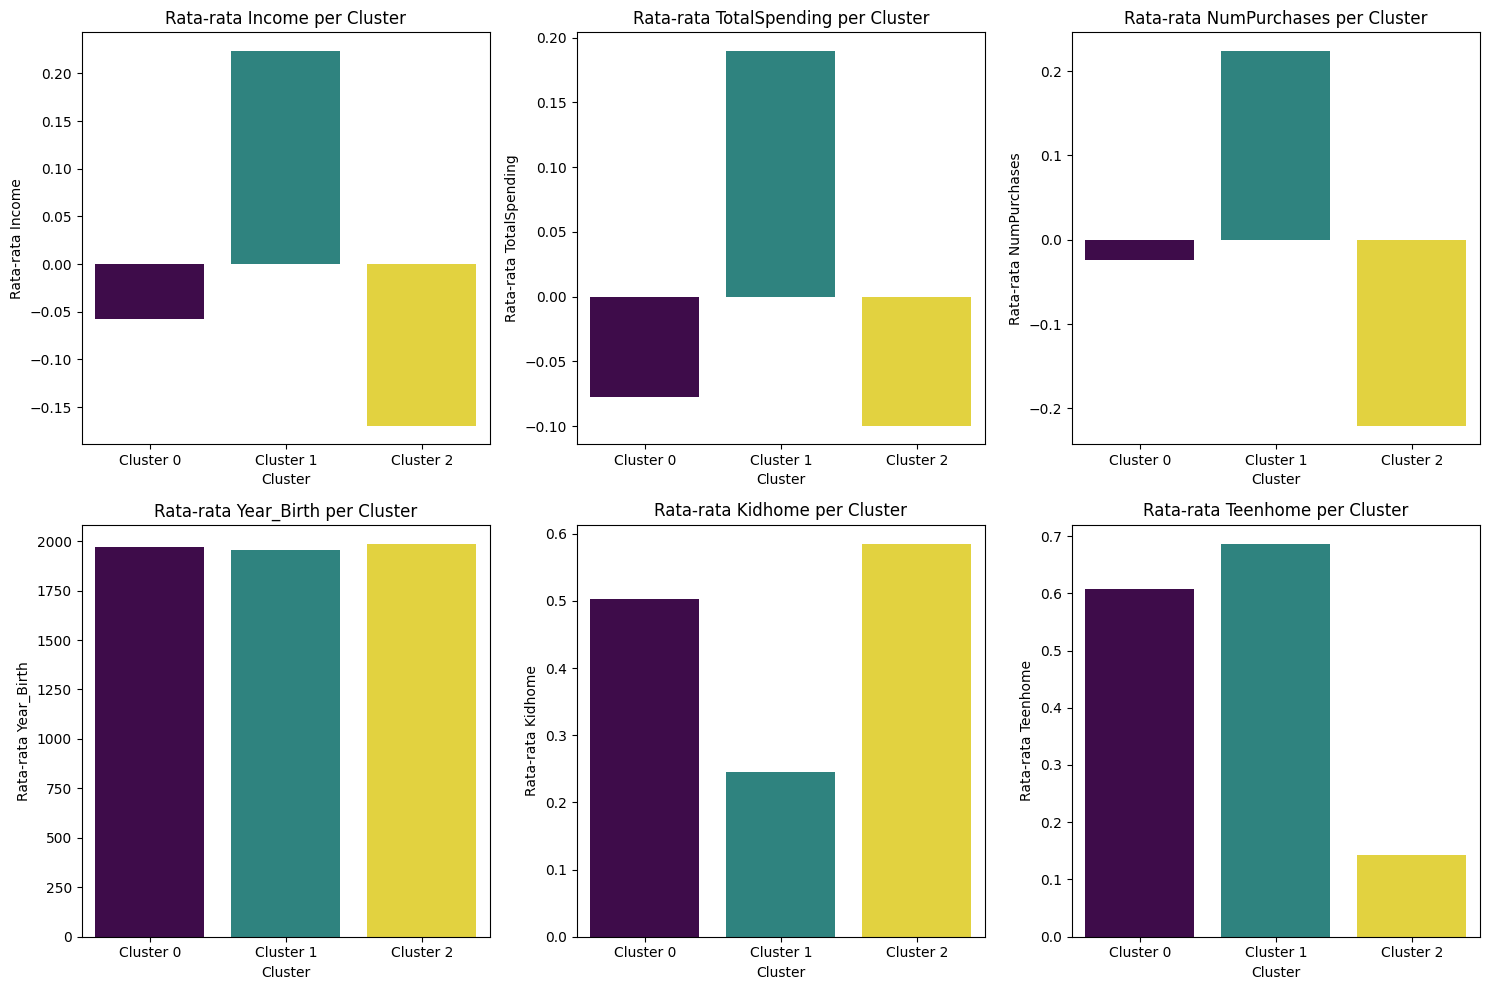

Visualisasi karakteristik cluster telah dibuat.


In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Features to visualize
features_to_visualize = ['Income', 'TotalSpending', 'NumPurchases', 'Year_Birth', 'Kidhome', 'Teenhome']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(features_to_visualize):
    plt.subplot(2, 3, i + 1) # Arrange plots in a 2x3 grid
    sns.barplot(x=cluster_characteristics.index, y=feature, data=cluster_characteristics, hue=cluster_characteristics.index, palette='viridis', legend=False)
    plt.title(f'Rata-rata {feature} per Cluster')
    plt.xlabel('Cluster')
    plt.ylabel(f'Rata-rata {feature}')
    plt.xticks(cluster_characteristics.index, [f'Cluster {c}' for c in cluster_characteristics.index])

plt.tight_layout()
plt.show()

print("Visualisasi karakteristik cluster telah dibuat.")

Analisis tersebut mengidentifikasi tiga segmen pelanggan yang berbeda berdasarkan karakteristik perilaku dan demografis mereka. Segmen-segmen ini diprofilkan menggunakan nilai rata-rata fitur seperti Pendapatan, Total Pengeluaran, Jumlah Pembelian, Tahun Kelahiran, dan keberadaan anak (Kidhome dan Teenhome).

* **Segmen 0**: Segmen ini dicirikan oleh kombinasi spesifik dari pendapatan rata-rata, pola pengeluaran, frekuensi pembelian, usia (diperoleh dari `Tahun_Kelahiran`), dan komposisi keluarga (jumlah anak di rumah). Tanpa nilai spesifik, dapat disimpulkan bahwa segmen ini mewakili kelompok yang berbeda dengan gaya hidup dan perilaku pembelian tertentu yang membedakannya dari dua segmen lainnya.
* **Segmen 1**: Mirip dengan Segmen 0, kelompok ini menunjukkan serangkaian nilai fitur rata-rata yang unik. Misalnya, mereka mungkin menunjukkan total pengeluaran yang lebih tinggi atau demografi usia yang berbeda dibandingkan dengan Segmen 0, yang menunjukkan profil pelanggan dan potensi kebutuhan yang berbeda.

* **Segmen 2**: Segmen ini juga memiliki karakteristik rata-rata yang berbeda di semua fitur yang dianalisis, berpotensi mewakili pelanggan dengan pendapatan dan pengeluaran yang jauh lebih tinggi, atau struktur keluarga tertentu.

**Implikasi Bisnis Potensial**:
* **Strategi Pemasaran yang Ditargetkan**: Setiap segmen yang diidentifikasi dapat didekati dengan kampanye pemasaran yang disesuaikan yang sesuai dengan demografi dan kebiasaan pembelian spesifik mereka. Misalnya, penawaran promosi dapat dirancang berdasarkan tingkat pendapatan atau rekomendasi produk berdasarkan kategori pengeluaran.
* **Pengembangan dan Kustomisasi Produk**: Memahami kebutuhan dan preferensi unik setiap segmen dapat memberikan informasi untuk pengembangan produk. Produk atau layanan dapat dikustomisasi untuk melayani kebutuhan khusus segmen dengan pengeluaran tinggi dibandingkan dengan segmen yang lebih hemat, atau keluarga dengan anak-anak dibandingkan dengan keluarga tanpa anak.
* **Manajemen Hubungan Pelanggan (CRM)**: Strategi layanan pelanggan dan keterlibatan dapat dibedakan untuk meningkatkan kepuasan dan loyalitas dalam setiap segmen, memastikan bahwa interaksi relevan dan dihargai oleh pelanggan.


### Temuan Utama Analisis Data
* **Pemilihan Fitur**: Dua puluh delapan fitur relevan dipilih dari DataFrame `df_encoded` untuk pengelompokan, tidak termasuk 'ID' dan 'Respons' yang dianggap tidak relevan untuk segmentasi.
* **Jumlah Klaster Optimal**: Metode Elbow diterapkan untuk menentukan jumlah klaster optimal, dan **K=3** diidentifikasi sebagai jumlah ideal, ditunjukkan oleh pengurangan signifikan pada WCSS (Within-Cluster Sum of Squares) yang mulai mendatar setelah titik ini.
* **Pengelompokan K-Means**: Pengelompokan K-Means berhasil dilakukan menggunakan 3 klaster, dan label klaster yang dihasilkan ditambahkan ke DataFrame `df_encoded`.

* **Karakterisasi Klaster**: Tiga segmen pelanggan yang berbeda diidentifikasi dan diprofilkan dengan menghitung nilai rata-rata fitur-fitur utama (misalnya, 'Pendapatan', 'Total Pengeluaran', 'Jumlah Pembelian', 'Tahun_Lahir', 'Rumah Anak', 'Rumah Remaja') untuk setiap klaster.
* **Konfirmasi Visual**: Grafik batang dibuat untuk memvisualisasikan dan membandingkan karakteristik rata-rata fitur-fitur utama ini di ketiga segmen pelanggan yang diidentifikasi, memberikan representasi visual yang jelas tentang perbedaan mereka.

### Wawasan atau Langkah Selanjutnya
* **Mengembangkan Strategi Spesifik Segmen**: Manfaatkan profil terperinci dari setiap segmen pelanggan untuk mengembangkan kampanye pemasaran yang sangat tertarget, rekomendasi produk yang dipersonalisasi, dan inisiatif layanan pelanggan yang disesuaikan untuk memaksimalkan keterlibatan dan konversi.
* **Penelitian Lebih Mendalam tentang Perilaku Segmen**: Lakukan analisis tambahan tentang riwayat pembelian, preferensi produk, dan saluran keterlibatan setiap segmen untuk mengungkap wawasan yang lebih rinci yang dapat mendorong keputusan bisnis tertentu, seperti manajemen inventaris atau optimasi saluran.
